In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("Social_Network_Ads.csv")

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [6]:
df = df.iloc[ : ,2: ]

In [7]:
df.sample(5)

,Age,EstimatedSalary,Purchased
29,31,18000,0
206,55,130000,1
318,45,32000,1
306,51,134000,0
12,20,86000,0


<H1> Train test split </H1>

In [9]:
from sklearn.model_selection import train_test_split

In [10]:
x_train, x_test ,y_train ,y_test = train_test_split(df.drop('Purchased',axis =1),df['Purchased'],
                                                    test_size=0.3,
                                                    random_state=0)

In [11]:
x_train.shape ,x_test.shape

((280, 2), (120, 2))

<h1>Standard Scalar </h1>

In [13]:
from sklearn.preprocessing import StandardScaler

In [14]:
scaler = StandardScaler()

In [15]:
# fit the scaler to the train set , it will learn the parameters 
scaler.fit(x_train)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [16]:
# transform train and test sets
x_train_scaled = scaler.transform(x_train)
x_test_scaled = scaler.transform(x_test)


the transformed data that we get will be a numpy array

In [18]:
scaler.mean_

array([3.78642857e+01, 6.98071429e+04])

In [19]:
x_train.head()

,Age,EstimatedSalary
92,26,15000
223,60,102000
234,38,112000
232,40,107000
377,42,53000


In [20]:
x_train_scaled

array([[-1.1631724 , -1.5849703 ],
       [ 2.17018137,  0.93098672],
       [ 0.0133054 ,  1.22017719],
       [ 0.20938504,  1.07558195],
       [ 0.40546467, -0.48604654],
       [-0.28081405, -0.31253226],
       [ 0.99370357, -0.8330751 ],
       [ 0.99370357,  1.8563962 ],
       [ 0.0133054 ,  1.24909623],
       [-0.86905295,  2.26126285],
       [-1.1631724 , -1.5849703 ],
       [ 2.17018137, -0.80415605],
       [-1.35925203, -1.46929411],
       [ 0.40546467,  2.2901819 ],
       [ 0.79762394,  0.75747245],
       [-0.96709276, -0.31253226],
       [ 0.11134522,  0.75747245],
       [-0.96709276,  0.55503912],
       [ 0.30742485,  0.06341534],
       [ 0.69958412, -1.26686079],
       [-0.47689368, -0.0233418 ],
       [-1.7514113 ,  0.3526058 ],
       [-0.67297331,  0.12125343],
       [ 0.40546467,  0.29476771],
       [-0.28081405,  0.06341534],
       [-0.47689368,  2.2901819 ],
       [ 0.20938504,  0.03449629],
       [ 1.28782302,  2.20342476],
       [ 0.79762394,

In [21]:
x_train_scaled = pd.DataFrame(x_train_scaled,columns=x_train.columns)
x_test_scaled = pd.DataFrame(x_test_scaled,columns=x_test.columns)

In [22]:
np.round(x_train.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,37.9,69807.1
std,10.2,34641.2
min,18.0,15000.0
25%,30.0,43000.0
50%,37.0,70500.0
75%,46.0,88000.0
max,60.0,150000.0


In [23]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,280.0,280.0
mean,0.0,0.0
std,1.0,1.0
min,-1.9,-1.6
25%,-0.8,-0.8
50%,-0.1,0.0
75%,0.8,0.5
max,2.2,2.3


<h1>Effect of the Scaling</h1>

Text(0.5, 1.0, 'After Scaling')

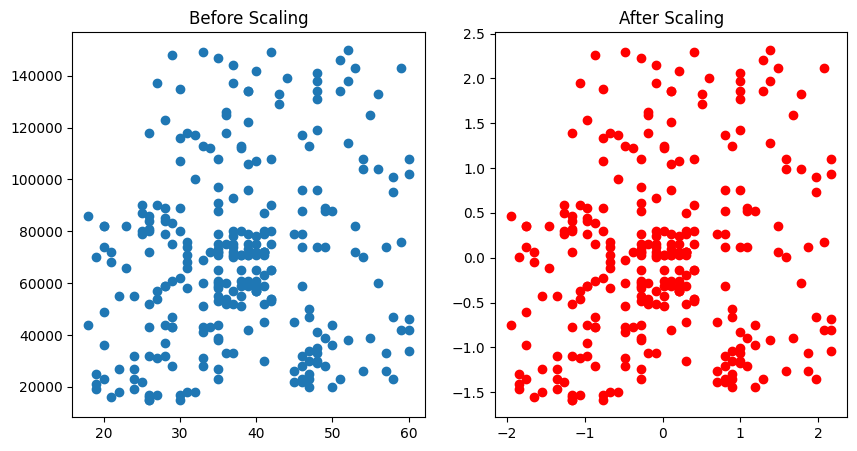

In [25]:
fig , (ax1, ax2) = plt.subplots(ncols=2, figsize =(10,5))

ax1.scatter(x_train['Age'],x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")

ax2.scatter(x_train_scaled['Age'],x_train_scaled['EstimatedSalary'],color="red")
ax2.set_title("After Scaling")

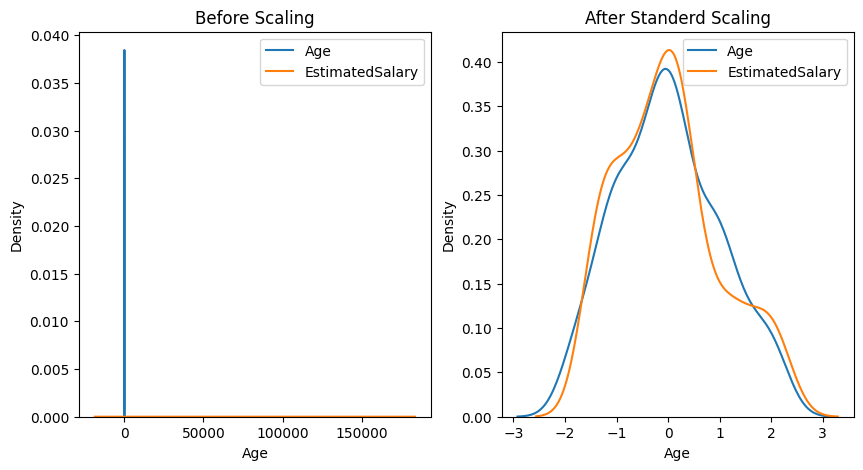

In [26]:
fig , (ax1, ax2) = plt.subplots(ncols=2, figsize =(10,5))

# Before Scaling
ax1.set_title("Before Scaling")
sns.kdeplot(x_train['Age'] ,ax=ax1,label='Age')
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1,label="EstimatedSalary")
ax1.legend()

# After Scaling
ax2.set_title("After Standerd Scaling")
sns.kdeplot(x_train_scaled['Age'] ,ax=ax2,label='Age')
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2,label="EstimatedSalary")
ax2.legend()

<h1>Comparision of Distributions</h1>

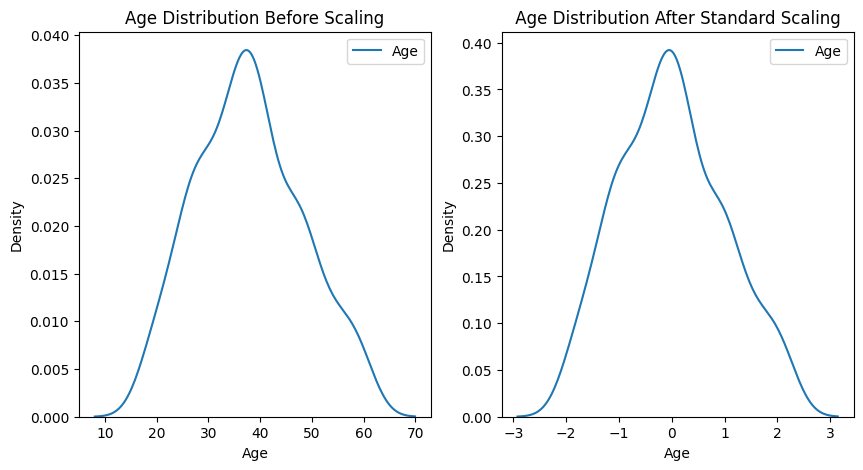

In [56]:
fig , (ax1, ax2) = plt.subplots(ncols=2, figsize =(10,5))

# Before Scaling  
ax1.set_title("Age Distribution Before Scaling")
sns.kdeplot(x_train['Age'] ,ax=ax1,label='Age')
ax1.legend()

# After Scaling 
ax2.set_title(" Age Distribution After Standard Scaling ")
sns.kdeplot(x_train_scaled['Age'] ,ax=ax2,label='Age')
ax2.legend()

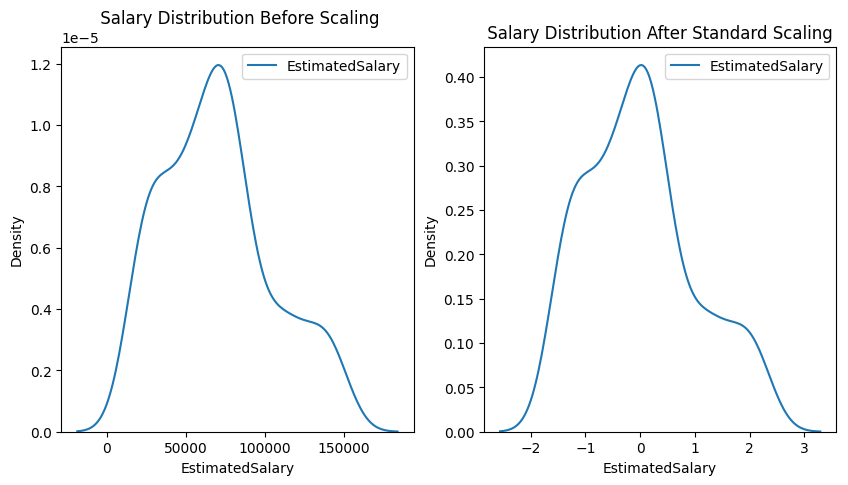

In [61]:
fig , (ax1, ax2) = plt.subplots(ncols=2, figsize =(10,5))

# Before Scaling  
ax1.set_title(" Salary Distribution Before Scaling")
sns.kdeplot(x_train['EstimatedSalary'],ax=ax1,label="EstimatedSalary")
ax1.legend()

# After Scaling 
ax2.set_title(" Salary Distribution After Standard Scaling ")
sns.kdeplot(x_train_scaled['EstimatedSalary'],ax=ax2,label="EstimatedSalary")
ax2.legend()

<h1>Why Scaling is Important </h1>